# MS 263 Final Project

## Assessing the Bacterial Community Composition of a Pesticide-Remediating Bioreactor in Salinas Valley, CA

#### Lindsay Yue

## Introduction

The Salinas River Valley is a major agricultural region on the California Central Coast, growing crops such as strawberries, lettuce, and brassicas (1). However, pesticides such as neonicotinoids, organophosphates, and pyrethroids are commonly applied, and are transported to nearby surface waters through agricultural runoff (1). In the Central Coast region, monitoring reveals widespread pesticide contamination, with multiple pesticides detected in most sites, often at concentrations above the EPA chronic-invertebrate threshold (2). In the Santa Maria River estuary, runoff and sediment containing chlorpyrifos and pyrethroids were toxic to invertebrates, and benthic stream communities were dominated by pollution tolerant taxa (3). Laboratory exposure to imidacloprid and chlorantraniliprole caused Daphnia magna mortality and altered gene expression in Pimephales promelas (4). In the Salinas Valley, women in closer residential proximity to pesticide application areas had increased cardiovascular risk factors (5).

A practical approach to reducing pesticide pollution is to treat agricultural wastewater on-site. Woodchip bioreactors are a bioremediation method commonly used to reduce nitrates through metabolic activity of resident microbial communities (6). Extensive research exists on nitrate bioremediation in these bioreactors (6), but less is known about their potential for pesticide removal. Existing research on pesticide bioremediation focuses on sorption, hydraulic retention times and characterizing naturally occurring bacterial communities (7, 8).

Microbial communities can respond to pollutants, such as pesticides. Soil communities exposed to pesticides have been found to exhibit lower diversity, different dominant taxa, and altered metabolic pathways (9, 10). French et al. (2020) (11) showed that E. coli engineered with petroleum hydrocarbon degradation genes added to contaminated soil horizontally transferred those genes to naturally occurring bacteria. Transferred genes persisted for over 60 days, and petroleum concentrations in the soil decreased by 46% (11). In groundwater contaminated with heavy metals and nitrates, horizontal gene transfer of heavy metal resistance, but not denitrifying genes occurred, suggesting not all functional genes are equally likely to be transferred (12).

In the Jue lab at CSUMB, preliminary research shows reduced imidacloprid concentrations after remediators were added to a woodchip bioreactor, but remediators do not dominate the community (13). It remains unknown whether horizontal gene transfer occurs, and if native taxa contribute to pesticide degradation. My project will use 16S sequencing data to characterize microbial community composition in the bioreactor. My objectives are:

1) Is alpha diversity in the bioreactor different in 2019 and 2024? 
2) Does alpha diversity change after pesticide-remediating bacteria are added? 
3) Is alpha diversity different between port 1 (inflow) and port 4 (outflow) of the bioreactor?

These findings will improve bioreactor design and reveal how the bacteria within the bioreactor adapt to environmental stressors such as pesticide pollution.


## Methods

#### Field Experiments:

To characterize changes in bacterial community composition in the bioreactor, field experiments were conducted during the 2019 and 2024 growing season at a bioreactor installed in the Salinas Valley. Sediment and water column samples were collected from the bioreactor for bacterial genomics analysis, and water quality parameters which included temperature, conductivity, salinity, dissolved oxygen, nitrate and turbidity were measured using a ProDSS instrument. Samples were collected for a couple weeks pre dosing, or before any bacteria were added to the bioreactor, and for a couple weeks post dosing, which is when known pesticide-remediating bacteria were actively being added to the bioreactor. 

#### Molecular Lab Work:

DNA from water and sediment samples was isolated using the DNeasy PowerSoil Pro and DNeasy PowerWater Sterivex kits from Qiagen. Afterwards, the isolated DNA underwent PCR to amplify the 16S gene amplicons. The PCR product was cleaned using magnetic beads, quantified for DNA concentration using a Qubit, and then the cleaned product was sequenced using an Illumina MiSeq system.

#### Computational Work and Data Analysis:

Raw sequence data was analyzed using QIIME 2 (14) to identify sequence variants and taxonomically classify samples. In R, a phyloseq object was created using QIIME2 outputs, and OTU tables were created and exported as .csv files. The OTU tables and sample metadata are the datasets used in this project. 

#### Data Manipulation

Import necessary packages

In [83]:
#Data manipulation
import pandas as pd

#Functions used for data preparation
from data_prep_tools import merged_data
from data_prep_tools import scatterplots

#Calculating alpha diversity
from skbio.diversity import alpha_diversity

#Plotting
import seaborn as sns
import matplotlib.pyplot as plt

#Statistical Analyses
from scipy.stats import shapiro
from scipy.stats import ttest_ind
import pingouin as pg

Import rarefied OTU datasets that were previously generated using QIIME 2 and R, and sample metadata. The rarefied OTU tables contain only the samples that were rarefied at 1000 reads. This accounts for uneven sequencing depth. Samples containing less than 1000 reads were discarded, and samples that had 1000 or more reads were subsampled 1000 times. 

In [84]:
BR19_OTU=pd.read_csv("data/BR19_OTUs_rarefied.csv", index_col=0)
BR24_OTU=pd.read_csv("data/BR24_OTUs_rarefied.csv", index_col=0)

BR19_md = pd.read_csv('data/BR_2019_metadata.tsv', sep='\t', index_col=0)
BR19_md['Datetime'] = pd.to_datetime(BR19_md['Date'].astype(str) + ' ' + BR19_md['Time'])
BR24_md = pd.read_csv('data/BR2024_metadata_F240_R220.tsv', sep='\t', index_col=0)
BR24_md['Datetime'] = pd.to_datetime(BR24_md['Date'].astype(str) + ' ' + BR24_md['Time'])


/var/folders/28/jbc5b_x11jv49kk_pyc43kd40000gn/T/ipykernel_3567/3233246884.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  BR19_md['Datetime'] = pd.to_datetime(BR19_md['Date'].astype(str) + ' ' + BR19_md['Time'])
/var/folders/28/jbc5b_x11jv49kk_pyc43kd40000gn/T/ipykernel_3567/3233246884.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  BR24_md['Datetime'] = pd.to_datetime(BR24_md['Date'].astype(str) + ' ' + BR24_md['Time'])


Create the merged datasets. This will include a dataframe that includes samples with rarefied OTUs, metadata, and alpha diversity metrics. This is done using the Merged_dataset.py module.

The data_prep_tools module contains the function merged_data. For this function, the metadata and rarefied OTU table are required inputs. From these rarefied OTU tables, the alpha diversity metrics, Shannon Diversitiy and Sobs (OTUs observed) were calculated and then merged with the rarefied OTUs and metadata. This was done with the 2019 and 2024 datasets.


In [85]:
#Create merged datasets
merged_BR19 = merged_data(BR19_OTU, BR19_md)
merged_BR24 = merged_data(BR24_OTU, BR24_md)

For BR19, I only want to analyze ports 1 and 4, so I will filter out samples collected at ports 2 and 3.

In [86]:
merged_BR19 = merged_BR19[(merged_BR19["Port"] == 1) | (merged_BR19["Port"] == 4)]
merged_BR19['Port'].unique()

array([1, 4])

In [87]:
#Separate out water and sediment from datasets
#By year
water19 = merged_BR19[(merged_BR19["SampleType"] == "Water")]
sed19 = merged_BR19[(merged_BR19["SampleType"] == "Sediment")]
water24 = merged_BR24[(merged_BR24["SampleType"] == "Water")]
sed24 = merged_BR24[(merged_BR24["SampleType"] == "Sediment")]

#Including both years
water=pd.concat([water19, water24], axis=0)
sediment=pd.concat([sed19, sed24], axis = 0)

Samples were collected multiple times a week, multiple times a day. This means samples may not be independent since samples were taken so often. I decided to test whether alpha samples collected on the same day, but different times ( AM or PM) were significantly correlated with each other. 2019 samples were collected four times a day, but I decided to just group them into AM (8:00:00, 11:00:00) and PM (14:00:00 and 17:00:00) to make the data easier to assess, and more comparable with 2024 data. 

First, reorganize and subset the data into pivot tables. Create pivot tables where alpha diversity measurements collected at different times on the same date are stored in separate columns. Then, plot alpha diversity metrics of samples taken from the same day but different times against each other in a scatterplot, and perform a linear regression to assess whether they are correlated. If they are significantly correlated, these samples may not be independent. 

In [88]:
#Make pivot table with Date, Shannon AM, Shannon PM, Sobs AM and Sobs PM columns. 
water19_corr=water19.pivot_table(index="Date",
        columns="AM.PM",
        values=["Shannon", "Sobs"])
water19_corr.columns = [f"{var} {ampm}" for var, ampm in water19_corr.columns]

sed19_corr=sed19.pivot_table(index="Date",
        columns="AM.PM",
        values=["Shannon", "Sobs"])
sed19_corr.columns = [f"{var} {ampm}" for var, ampm in sed19_corr.columns]



water24_corr=water24.pivot_table(index="Date",
        columns="AM.PM",
        values=["Shannon", "Sobs"])
water24_corr.columns = [f"{var} {ampm}" for var, ampm in water24_corr.columns]

sed24_corr=sed24.pivot_table(index="Date",
        columns="AM.PM",
        values=["Shannon", "Sobs"])
sed24_corr.columns = [f"{var} {ampm}" for var, ampm in sed24_corr.columns]



2019 Water Shannon Diversity: AM vs PM
p-value = 0.3950429885289665


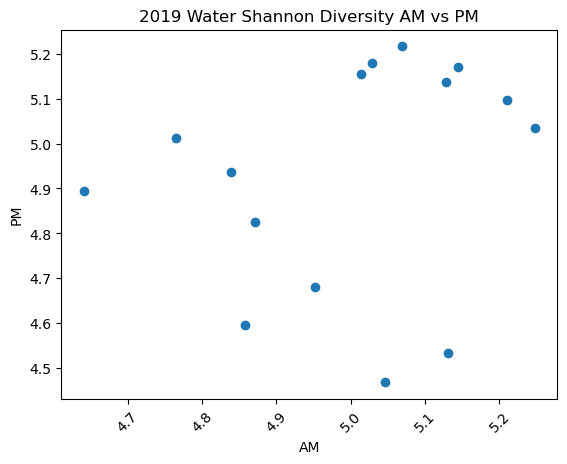

2019 Water Observed Taxa: AM vs PM
p-value = 0.15745891789741648


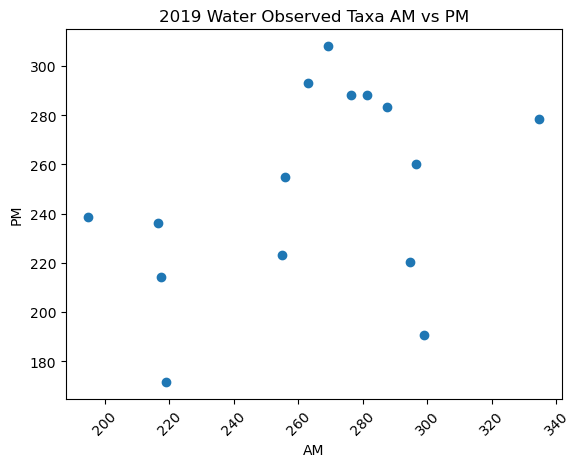

2019 Sediment Shannon Diversity: AM vs PM
p-value = 0.17712008063329088


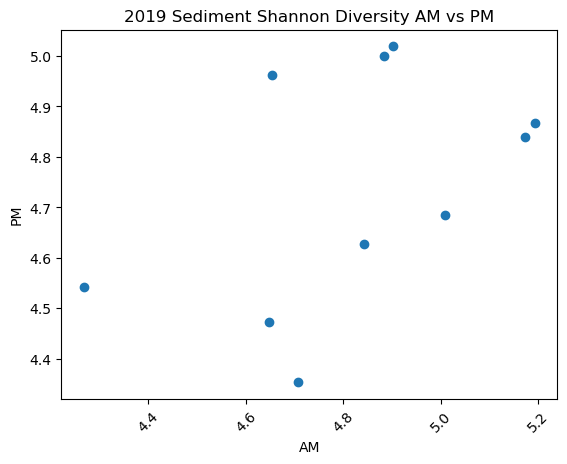

2019 Sediment Observed Taxa: AM vs PM
p-value = 0.7079599801529085


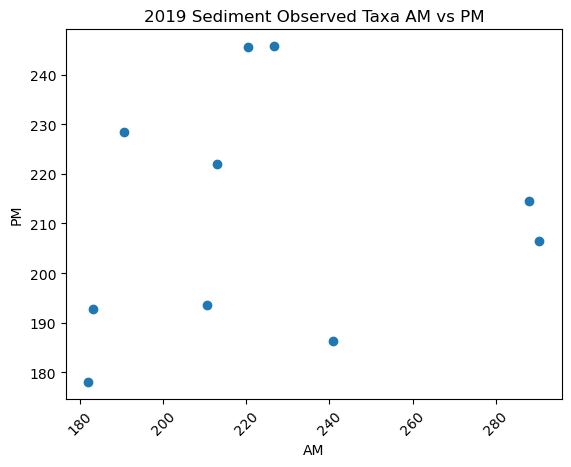

2024 Water Shannon Diversity: AM vs PM
p-value = 0.06177599713124295


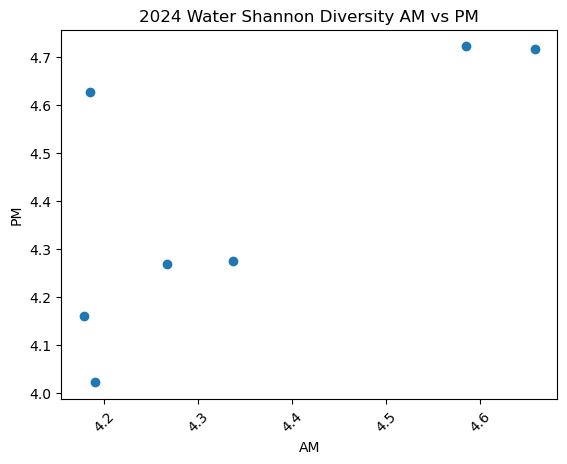

2024 Water Observed Taxa: AM vs PM
p-value = 0.06862000548869897


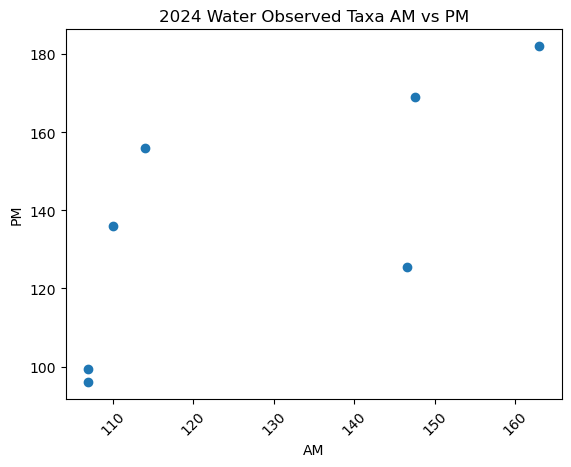

2024 Sediment Shannon Diversity: AM vs PM
p-value = 0.7157175297702679


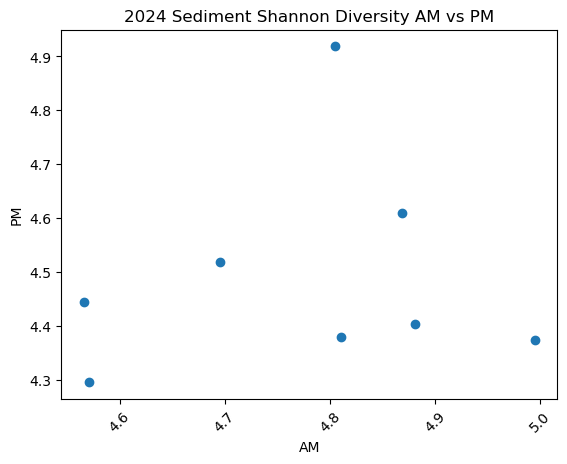

2024 Sediment Observed Taxa: AM vs PM
p-value = 0.6818625135702523


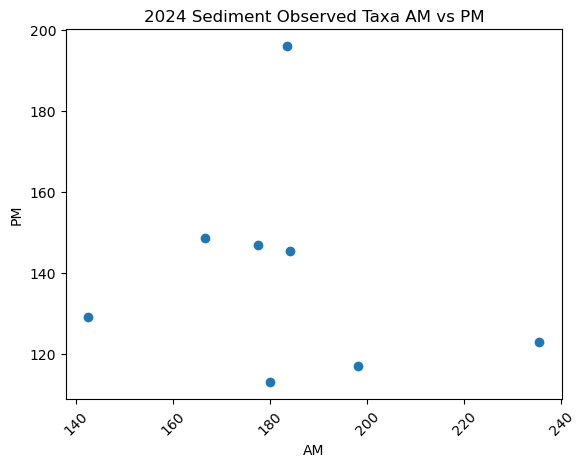

,Dataset,Metric,Comparison,Slope,Intercept,R2,p_value,n
0,2019 Water,Shannon Diversity,AM vs PM,0.348447,3.188038,0.056172,0.395043,15
1,2019 Water,Observed Taxa,AM vs PM,0.406373,142.646936,0.147571,0.157459,15
2,2019 Sediment,Shannon Diversity,AM vs PM,0.394977,2.829526,0.214966,0.177120,10
3,2019 Sediment,Observed Taxa,AM vs PM,0.083839,192.498143,0.018494,0.707960,10
4,2024 Water,Shannon Diversity,AM vs PM,1.047633,-0.151924,0.534894,0.061776,7
5,2024 Water,Observed Taxa,AM vs PM,1.011377,8.402455,0.516982,0.068620,7
6,2024 Sediment,Shannon Diversity,AM vs PM,0.199657,3.539290,0.023727,0.715718,8
7,2024 Sediment,Observed Taxa,AM vs PM,-0.173497,171.700878,0.029964,0.681863,8


In [89]:
#Plot AM samples against PM samples
scatterplots(
    datasets={
        "2019 Water": water19_corr,
        "2019 Sediment": sed19_corr,
        "2024 Water": water24_corr,
        "2024 Sediment": sed24_corr
    },
    plot_variables=['Shannon', 'Sobs'],
    labels={'Shannon': 'Shannon Diversity', 'Sobs': 'Observed Taxa'},
    group=['AM', 'PM']
)


There were no significant correlations between the alpha diversity metrics of samples collected in the AM and PM. This suggests that samples collected in the morning and afternoon of the same day are independent, and can be treated as such in further analyses. In 2024, in each location only one sample was taken in the morning and one in the afternoon, so that dataset is fine. In 2019, there were two samples taken in the morning, and two in the afternoon. I plan to group samples by AM and PM, so that the two samples taken in the morning on the same day, in the same location are averaged, and same with the two samples collected in the afternoon. 

In [63]:
#Group 2019 samples into AM and PM 
water19_grouped = (
    water19
    .groupby(['Date', 'Year', 'Port', 'SampleType', 'Dosing', 'AM.PM'])
    .mean(numeric_only=True)
    .reset_index()
)


sed19_grouped = (
    sed19
    .groupby(['Date', 'Year', 'Port', 'SampleType', 'Dosing', 'AM.PM'])
    .mean(numeric_only=True)
    .reset_index()
)


In [64]:
water_grouped = (
    water
    .groupby(['Date', 'Year', 'Port', 'SampleType', 'Dosing', 'AM.PM'])
    .mean(numeric_only=True)
    .reset_index()
)


sediment_grouped = (
    sediment
    .groupby(['Date', 'Year', 'Port', 'SampleType', 'Dosing', 'AM.PM'])
    .mean(numeric_only=True)
    .reset_index()
)


## Results

Now that the data is in the right format, we can proceed with analyses. First, plot violin plots of the relevant comparison groups. Violin plots, with box plots inside will show the distributions of the data, as well as the summary statistics within the boxplot. Figures generated will be saved in the Figures directory as .png files.

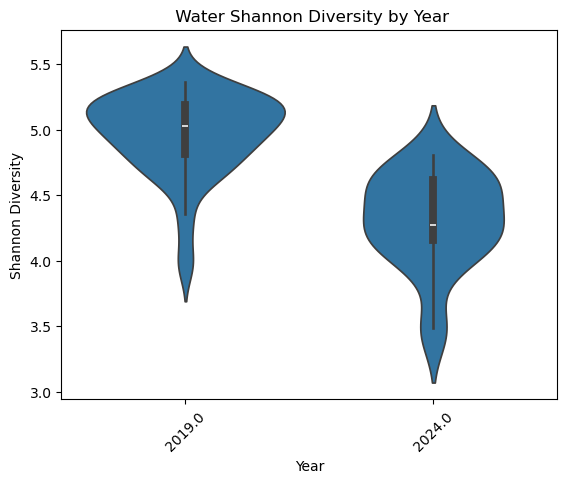

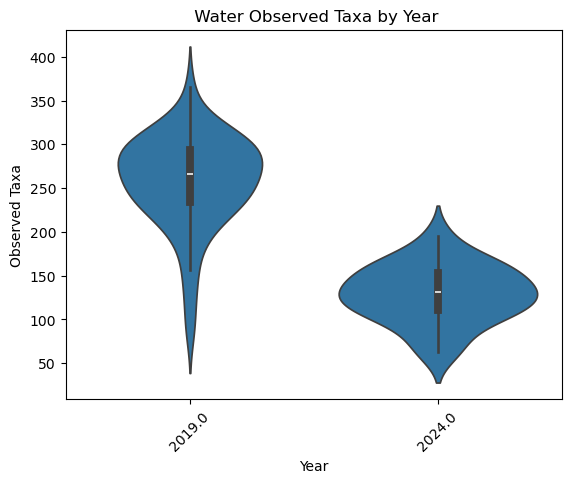

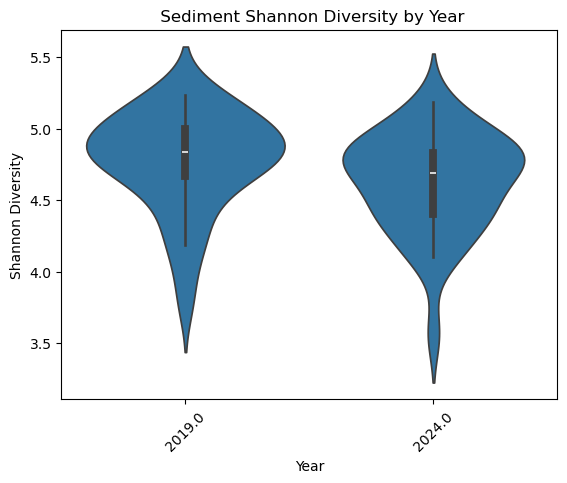

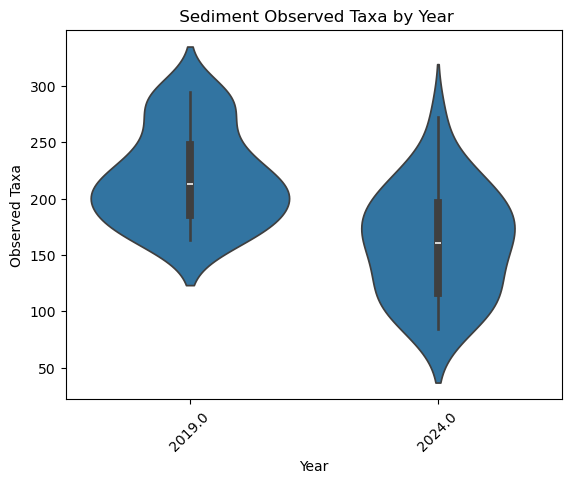

In [65]:
#Plot violin plots showing the Shannon diversity and observed taxa from water samples and sediment samples grouped by year.

plot_variables = ['Shannon', 'Sobs']

labels = {'Shannon': 'Shannon Diversity', 'Sobs': 'Observed Taxa'}

datasets = {"Water": water_grouped, "Sediment": sediment_grouped}
for dataset_name, dataset in datasets.items():
    for var in plot_variables:
        plt.figure()
        sns.violinplot(data=dataset, x='Year', y=var, inner='box')
        plt.title(f" {dataset_name} {labels[var]} by Year")
        plt.xlabel("Year")
        plt.ylabel(labels[var])
        plt.xticks(rotation=45)
        plt.savefig(f"Figures/{dataset_name} {labels[var]} by Year Violin Plot grouped data") 
        plt.show()

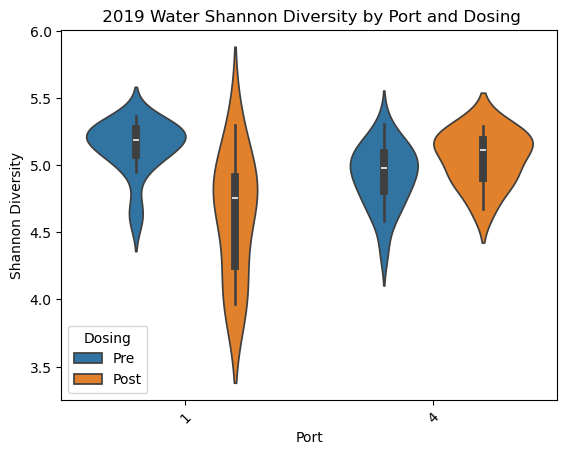

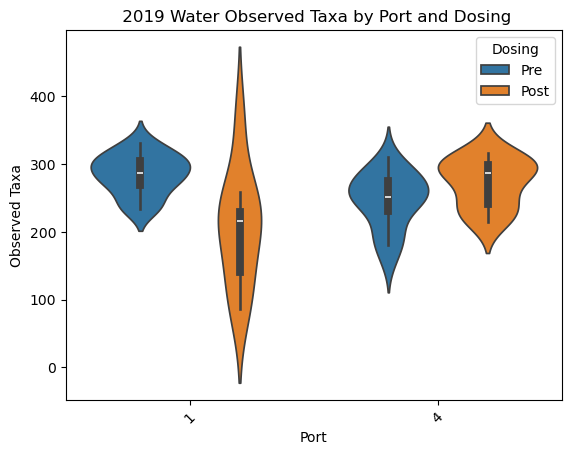

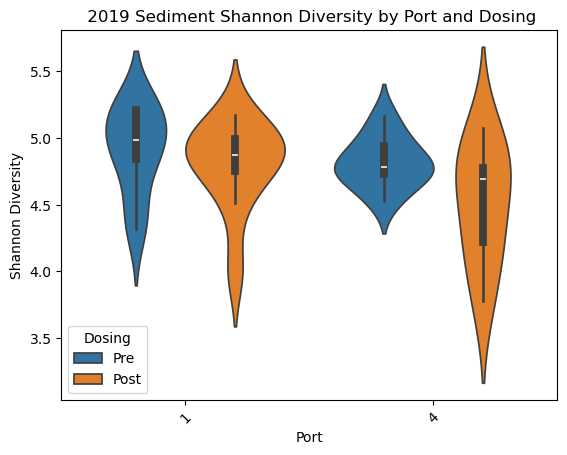

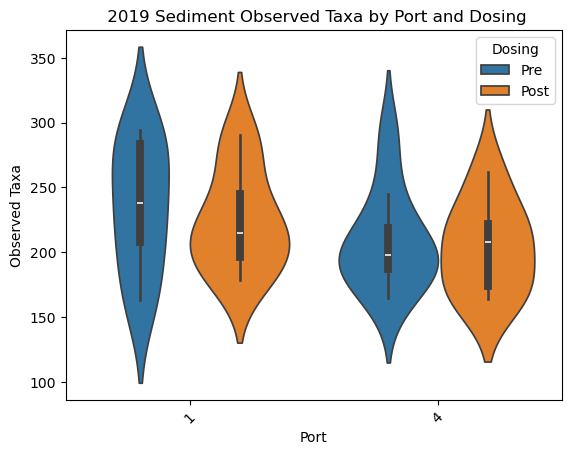

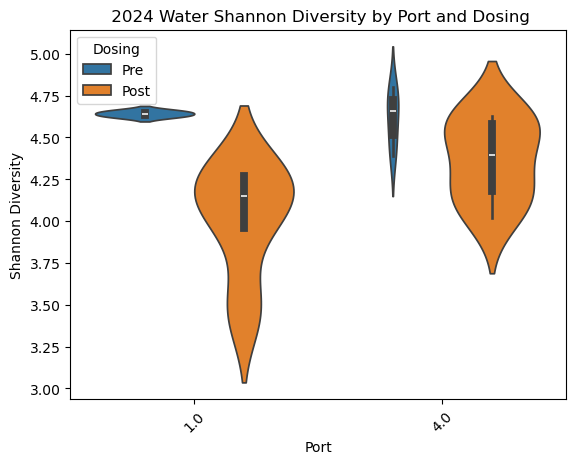

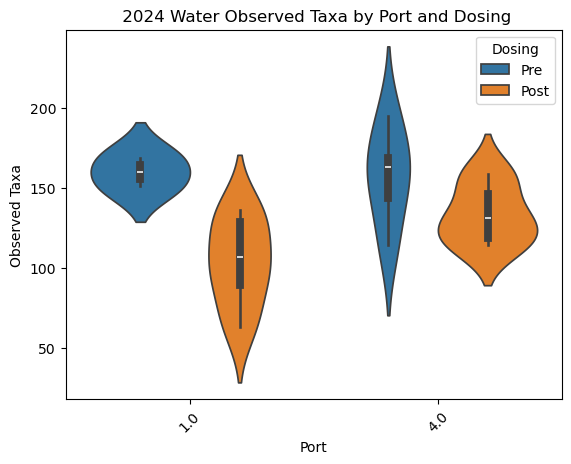

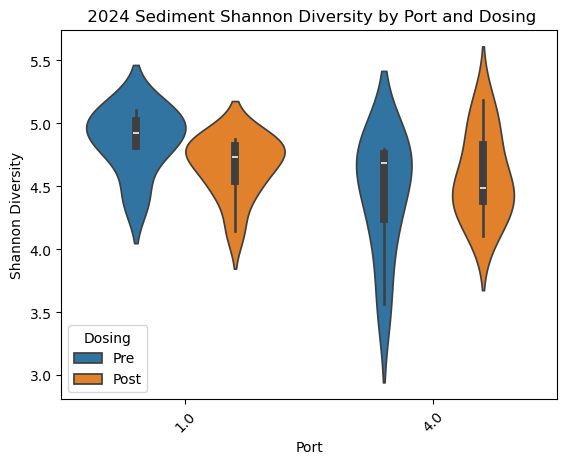

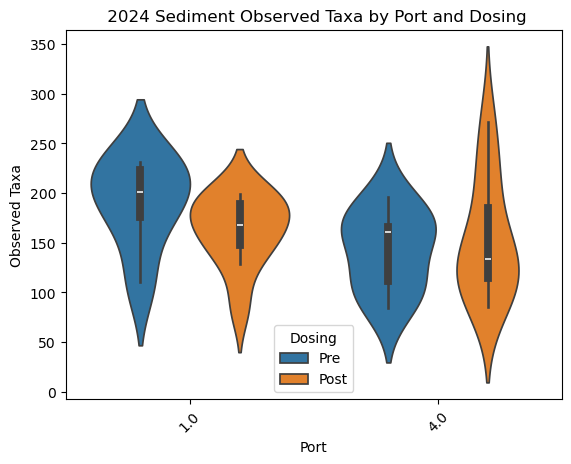

In [66]:
#Plot violin plots showing the Shannon diversity and observed taxa from 2019 water, 2019 sediment, 2024 water and 2024 sediment samples grouped by port and then grouped by dosing.

plot_variables = ['Shannon', 'Sobs']

labels = {'Shannon': 'Shannon Diversity', 'Sobs': 'Observed Taxa'}

datasets = {"2019 Water": water19_grouped, "2019 Sediment": sed19_grouped, "2024 Water": water24, "2024 Sediment": sed24}

for dataset_name, dataset in datasets.items():
    for var in plot_variables:
        plt.figure()
        sns.violinplot(data=dataset, x='Port', y=var, hue = 'Dosing', inner='box')
        plt.title(f" {dataset_name} {labels[var]} by Port and Dosing")
        plt.xlabel("Port")
        plt.ylabel(labels[var])
        plt.xticks(rotation=45)
        plt.savefig(f"Figures/{dataset_name} {labels[var]} by Port and Dosing Violin Plot")
        plt.show()

From looking at these violin plots, the distributions may not be normal, and the variances do not all look similar. Next, I will perform normality tests. First, I will perform Shapiro-Wilk tests on my different groupings.

In [67]:
#Shapiro-Wilk test on Shannon diversitiy and observed taxa from water and sediment samples grouped by year.
print("Water Shannon", shapiro(water_grouped['Shannon']))
print("Water Sobs", shapiro(water_grouped['Sobs']))
print("Sediment Shannon", shapiro(sediment_grouped['Shannon']))
print("Sediment Sobs", shapiro(sediment_grouped['Sobs']))

Water Shannon ShapiroResult(statistic=np.float64(0.9182587451188892), pvalue=np.float64(6.441827488694393e-05))
Water Sobs ShapiroResult(statistic=np.float64(0.943459842429049), pvalue=np.float64(0.0012642966526501076))
Sediment Shannon ShapiroResult(statistic=np.float64(0.9412616149749435), pvalue=np.float64(0.003079161166886554))
Sediment Sobs ShapiroResult(statistic=np.float64(0.9773892042108875), pvalue=np.float64(0.25250677662972654))


In [68]:
#Shapiro-Wilk test showing the Shannon diversity and observed taxa from 2019 water, 2019 sediment, 2024 water, and 2024 sediment grouped by port and grouped by dosing
print("Water 2019 Shannon", shapiro(water19_grouped['Shannon']))
print("Water 2019 Sobs", shapiro(water19_grouped['Sobs']))
print("Sediment 2019 Shannon", shapiro(sed19_grouped['Shannon']))
print("Sediment 2019 Sobs", shapiro(sed19_grouped['Sobs']))
print("Water 2024 Shannon", shapiro(water24['Shannon']))
print("Water 2024 Sobs", shapiro(water24['Sobs']))
print("Sediment 2024 Shannon", shapiro(sed24['Shannon']))
print("Sediment 2024 Sobs", shapiro(sed24['Sobs']))

Water 2019 Shannon ShapiroResult(statistic=np.float64(0.8806275340972675), pvalue=np.float64(3.194117265301759e-05))
Water 2019 Sobs ShapiroResult(statistic=np.float64(0.9378482699474172), pvalue=np.float64(0.0047633363981638395))
Sediment 2019 Shannon ShapiroResult(statistic=np.float64(0.9162284868337739), pvalue=np.float64(0.011117658693262969))
Sediment 2019 Sobs ShapiroResult(statistic=np.float64(0.9252945711186679), pvalue=np.float64(0.020317855161662093))
Water 2024 Shannon ShapiroResult(statistic=np.float64(0.9147600600464804), pvalue=np.float64(0.051502695398667316))
Water 2024 Sobs ShapiroResult(statistic=np.float64(0.9838833709302394), pvalue=np.float64(0.9604997680165659))
Sediment 2024 Shannon ShapiroResult(statistic=np.float64(0.9417114243655682), pvalue=np.float64(0.07619018924969027))
Sediment 2024 Sobs ShapiroResult(statistic=np.float64(0.9717327056297818), pvalue=np.float64(0.5295220388063093))


From assessing the variance and normality of the data, I have decided to use a Welch's t-test to compare whether mean alpha diversity metrics vary by year. Not all of my data is normal, and has equal variance. Welch's t-test assumes data are normal, but does not assume equal variances. While the Mann Whitney U test is nonparametric, it assumes equal variances, so neither test is perfect for all my data. 

In [81]:
#Welch's t-test of the Shannon diversity and observed taxa from water and sediment samples grouped by year

plot_variables = ['Shannon', 'Sobs']

labels = {'Shannon': 'Shannon Diversity', 'Sobs': 'Observed Taxa'}

datasets = {
    "2019 Water": water19_grouped,
    "2019 Sediment": sed19_grouped,
    "2024 Water": water24,
    "2024 Sediment": sed24
}

results_year = []

# Water: 2019 vs 2024
for var in plot_variables:
    y2019 = water19_grouped[var]
    y2024 = water24[var]

    stat, p = ttest_ind(y2019, y2024, equal_var=False)  # Welch's t-test when equal_var=False

    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = ''
        
    results_year.append({
        "Dataset": "Water",
        "Metric": labels[var],
        "Test": "2019 vs 2024",
        "n 2019": len(y2019),
        "n 2024": len(y2024),
        "t-statistic": stat,
        "p-value": p,
        "Significance": sig
    })

# Sediment: 2019 vs 2024
for var in plot_variables:
    y2019 = sed19_grouped[var]
    y2024 = sed24[var]

    stat, p = ttest_ind(y2019, y2024, equal_var=False)  
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = ''
        
    results_year.append({
        "Dataset": "Sediment",
        "Metric": labels[var],
        "Test": "2019 vs 2024",
        "n 2019": len(y2019),
        "n 2024": len(y2024),
        "t-statistic": stat,
        "p-value": p,
        "Significance": sig
    })

Welch_results_year_df = pd.DataFrame(results_year)
Welch_results_year_df

,Dataset,Metric,Test,n 2019,n 2024,t-statistic,p-value,Significance
0,Water,Shannon Diversity,2019 vs 2024,59,23,7.787623,3.461884e-09,***
1,Water,Observed Taxa,2019 vs 2024,59,23,13.282200,4.578256e-20,***
2,Sediment,Shannon Diversity,2019 vs 2024,35,33,1.779155,7.983419e-02,
3,Sediment,Observed Taxa,2019 vs 2024,35,33,5.418616,9.931253e-07,***


For assessing whether alpha diversity metrics are different between port, dosing, and the interaction between port and dosing, I will conduct a two-way ANOVA. 

In [90]:
#Two-way ANOVA of the Shannon diversity and observed taxa from water and sediment samples grouped by port and dosing

plot_variables = ['Shannon', 'Sobs']

labels = { 'Shannon': 'Shannon Diversity', 'Sobs': 'Observed Taxa'}

datasets = {
    "2019 Water": water19_grouped,
    "2019 Sediment": sed19_grouped,
    "2024 Water": water24,
    "2024 Sediment": sed24
}

results = []

for dataset_name, dataset in datasets.items():
    for var in plot_variables:

        n = len(dataset[var])

        anova_table = pg.anova(
            data=dataset,
            dv=var,
            between=['Dosing', 'Port'],
            detailed=True
        )

        
        for _, row in anova_table.iterrows():

            if row["p-unc"] < 0.001:
                sig = '***'
            elif row["p-unc"] < 0.01:
                sig = '**'
            elif row["p-unc"] < 0.05:
                sig = '*'
            else:
                sig = ''
    
            results.append({
                "Dataset": dataset_name,
                "Metric": labels[var],
                "Effect": row["Source"],
                "n": n,
                "DF": row["DF"],
                "F": row["F"],
                "p_value": row["p-unc"],
                "np2": row["np2"],
                "Significance": sig
            })

anova_results = pd.DataFrame(results)

anova_results

IndentationError: unexpected indent (4098592170.py, line 30)

## Conclusions

From this analysis, I obtained some preliminary results. I found that the mean alpha diversity was different in water and sediment samples collected in different years, with all mean alpha diversity metrics lower in 2024 than in 2019 (p<0.001), except for mean Shannon diversity between 2019 and 2024 in sediment, which was not signficant. This result addresses Question 1. Between 2019 and 2024, the bioreactor was actively used for research in 2020 and 2021. The bioreactor was used much less from 2022-2024. This long period without research activity could have caused the microbial communities to change, as when the bioreactor is not in use, wastewater is not continuously pumped through. The microbial composition could have also changed as the bioreactor aged, as it was newly built in 2019. 

In sediment samples from both years, mean alpha diversity did not significantly differ between port 1 and port 4, between pre and post dosing, and their interactions. In 2019 water samples, there was a significant dosing and port interaction for both Shannon diversity and observed taxa (p<0.001), which means that the effect of pre or post dosing is different between port 1 and port 4. There was also a significant effect of dosing alone (p<0.05). In 2024 water samples, there was a significant difference in mean Shannon diversity explained by dosing alone (p<0.01) and port alone (p<0.05), but not their interaction. There was also a significant effect of dosing for mean observed taxa (p<0.05). These results address Question 2 and Question 3.

Overall, alpha diversity in water communities were more influenced by dosing, port, and the interaction between port and dosing than sediment communities, especially in 2019. Sediment samples were collected from the bottom of the bioreactor below the woodchips, while water samples were collected from the bioreactor water column. In the bioreactor, water flows through from port 1 to port 4, and perhaps the water column could have had different alpha diversity metrics in port 1 and port 4 in 2024 because the water column was constantly disturbed by wastewater flowing through. Sediment communities may have been more stable, and less affected by flowing wastewater. Mean alpha diversity may have been higher pre-dosing than post-dosing because post-dosing, several strains of known pesticide-remediating bacteria grown in 1L liquid cultures were being poured into the bioreactor. This addition of new bacteria could have led these bacteria strains to dominate in the bioreactor post-dosing, or disrupt the community dynamics enough to reduce species richness and eveness of the existing bacterial community. 

## Future Work

In the near term, I would like to combine alpha diversity analyses with beta diversity analyses, which were previously done. I also would like to do Tukey's post-hoc tests on the significant ANOVA results. I also would like to determine which taxa are most prevalent in the bioreactor at the different ports, pre and post dosing, and the different years, and try to identify the bacteria species we added into the bioreactor. The OTUs along with a taxonomic classifier are used to identify the bacteria present in a sample. Currently, the taxonomic classifier I am using can identify bacteria present to phylum or class, but it is not great at identifying them down to genus or species. I would like to train the taxonomic classifier to more reliably identify bacteria down to genus or species in our samples.

In the long term, I plan to incorporate data from 2025 experiments into my alpha diversity analyses. In 2025, experiments were conducted at two additional bioreactors, and it would be interesting to see whether alpha diversity patterns are similar in different bioreactors. For my thesis, I also would like to identify functional genes present in the bioreactor by using shotgun metagenomics sequencing. This sequencing method sequences all the genes present in the environmental sample, instead of just a region of the 16S gene. While this method is more costly and computationally intensive, understanding the functional genes present in the bioreactor can help with understanding how microbial communities change, and can inform better bioreactor design. 

## AI Statement

ChatGPT-5.5 Thinking was used to develop some portions of code. I initally created some code to make boxplots for 2019 data. I then wanted to create a loop that could create these boxplots for both years, without having to do it twice. I have many different data subset combinations that I wanted to plot, and conduct statistical tests on. I used ChatGPT to generate portions of my loops. Portions of code I used to generate the violin plots and Welch's t-test were generated by Chatgpt. ChatGPT generated the nested loops format I used for my violin plots and Welch's t-test, as well as the tables for the Welch's t-test and two-way ANOVAs, the code with the general format:

plot_variables = []

labels = {}

datasets = {
}

for dataset_name, dataset in datasets.items():
    for var in plot_variables:

Chatgpt generated the code that created an empty results list, and then appends a list of a dictionary of results, and turns that into a dataframe, and the code I needed to loop through the dataframe, one row at a time for the ANOVAs: for _, row in anova_table.iterrows():. I also used Chatgpt to generate the last line of code when making my pivot tables, the code that reads x_corr.columns = [f"{var} {ampm}" for var, ampm in x_corr.columns]. The Chatgpt code makes my table columns look better, by taking the tuples that were created and making them into strings, which is easier to work with when plotting and looping. 


## References

1. Joseph SV, Martin T, Steinmann K, Kosina P. 2017. Outlook of Pyrethroid Insecticides for Pest Management in the Salinas Valley of California. J Integr Pest Manag 8:6.
2. Sandstrom MW, Nowell LH, Mahler BJ, Van Metre PC. 2022. New-generation pesticides are prevalent in California’s Central Coast streams. Sci Total Environ 806:150683.
3. Anderson B, Phillips B, Hunt J, Siegler K, Voorhees J, Smalling K, Kuivila K, Hamilton M, Ranasinghe JA, Tjeerdema R. 2014. Impacts of pesticides in a Central California estuary. Environ Monit Assess 186:1801–1814.
4. Stinson SA, Hasenbein S, Connon RE, Deng X, Alejo JS, Lawler SP, Holland EB. 2022. Agricultural surface water, imidacloprid, and chlorantraniliprole result in altered gene expression and receptor activation in Pimephales promelas. Sci Total Environ 806:150920.
5. Calderon L, Warner M, Gunier RB, Rauch S, Hazard KG, Kogut K, Eskenazi B, Torres JM. 2024. Residential proximity to agricultural pesticide use and cardiovascular disease risk factors among adult Latina women in California’s Salinas Valley. Am J Epidemiol 193:1583–1591.
6. Lee S, Cho M, Sadowsky MJ, Jang J. 2023. Denitrifying Woodchip Bioreactors: A Microbial Solution for Nitrate in Agricultural Wastewater—A Review. J Microbiol 61:791–805.
7. Wrightwood OM, Hattaway ME, Young TM, Bischel HN. 2022. Assessment of Woodchip Bioreactor Characteristics and Their Influences on Joint Nitrate and Pesticide Removal. ACS EST Water 2:106–116.
8. Bouteh E, Ahmadi N, Abbasi M, Torabian A, van Loosdrecht MCM, Ducoste J. 2021. Biodegradation of organophosphorus pesticides in moving bed biofilm reactors: Analysis of microbial community and biodegradation pathways. J Hazard Mater 408:124950.
9. Ewere EE, White S, Mauleon R, Benkendorff K. 2024. Soil microbial communities and degradation of pesticides in greenhouse effluent through a woodchip bioreactor. Environ Pollut 359:124561.
10. Gangola S, Joshi S, Bhandari G, Pant G, Sharma A, Perveen K, Bukhari NA, Rani R. 2023. Exploring microbial diversity responses in agricultural fields: a comparative analysis under pesticide stress and non-stress conditions. Front Microbiol 14.
11. French KE, Zhou Z, Terry N. 2020. Horizontal ‘gene drives’ harness indigenous bacteria for bioremediation. Sci Rep 10:15091.
12. Hemme CL, Green SJ, Rishishwar L, Prakash O, Pettenato A, Chakraborty R, Deutschbauer AM, Van Nostrand JD, Wu L, He Z, Jordan IK, Hazen TC, Arkin AP, Kostka JE, Zhou J. 2016. Lateral Gene Transfer in a Heavy Metal-Contaminated-Groundwater Microbial Community. mBio 7:10.1128/mbio.02234-15.
13. Snook M, Machuca C, Jue N. 2023. Dynamics of microbial remediation of imidacloprid in a research bioreactor system. Poster presented at: CSU-WATER Annual Conference; April 2023; California State University, Monterey Bay, CA.
14. Bolyen E, Rideout JR, Dillon MR, Bokulich NA, Abnet CC, Al-Ghalith GA, Alexander H, Alm EJ, Arumugam M, Asnicar F, Bai Y, Bisanz JE, Bittinger K, Brejnrod A, Brislawn CJ, Brown CT, Callahan BJ, Caraballo-Rodríguez AM, Chase J, Cope EK, Da Silva R, Diener C, Dorrestein PC, Douglas GM, Durall DM, Duvallet C, Edwardson CF, Ernst M, Estaki M, Fouquier J, Gauglitz JM, Gibbons SM, Gibson DL, Gonzalez A, Gorlick K, Guo J, Hillmann B, Holmes S, Holste H, Huttenhower C, Huttley GA, Janssen S, Jarmusch AK, Jiang L, Kaehler BD, Kang KB, Keefe CR, Keim P, Kelley ST, Knights D, Koester I, Kosciolek T, Kreps J, Langille MGI, Lee J, Ley R, Liu Y-X, Loftfield E, Lozupone C, Maher M, Marotz C, Martin BD, McDonald D, McIver LJ, Melnik AV, Metcalf JL, Morgan SC, Morton JT, Naimey AT, Navas-Molina JA, Nothias LF, Orchanian SB, Pearson T, Peoples SL, Petras D, Preuss ML, Pruesse E, Rasmussen LB, Rivers A, Robeson MS, Rosenthal P, Segata N, Shaffer M, Shiffer A, Sinha R, Song SJ, Spear JR, Swafford AD, Thompson LR, Torres PJ, Trinh P, Tripathi A, Turnbaugh PJ, Ul-Hasan S, van der Hooft JJJ, Vargas F, Vázquez-Baeza Y, Vogtmann E, von Hippel M, Walters W, Wan Y, Wang M, Warren J, Weber KC, Williamson CHD, Willis AD, Xu ZZ, Zaneveld JR, Zhang Y, Zhu Q, Knight R, Caporaso JG. 2019. Reproducible, interactive, scalable and extensible microbiome data science using QIIME 2. Nat Biotechnol 37:852–857.

